# Run-2 Instrumentation Read — did the unwind + 3% haircut do what we think?

Reads the newly-instrumented `universe_daily_*.csv` to answer, from data instead of inference:

1. **Where did the clean names' ~4% P&L give-back go?** (lost `none`-window quoting vs unwind fills)
2. **Do the trapped names' leaned exits actually execute?** (`time_ramp`/`time_cliff` fill counts)
3. **How often does the 3% residual haircut actually bite?** (`residual_marked` frequency)
4. **What is the daily liquidation cost per name?** (`pnl_mid_mark - pnl_pkr`)

This is the check-before-changing-code step: confirm the diagnosis before the inventory-gate fix + size sweep. Run All.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

RESULTS = Path('/Users/shazzak/Capital Stake - Results')
# newest instrumented daily file
d = pd.read_csv(sorted(RESULTS.glob('universe_daily_*.csv'))[-1])
d['date'] = pd.to_datetime(d['date'])
# ranked file for the clean-portfolio membership
r = pd.read_csv(sorted(RESULTS.glob('universe_ranked_*.csv'))[-1])
PORT = sorted(r[(r.mid_pnl>0)&(r.unclean_liq_days<=3)]['symbol'].tolist())
mid = d[d.config=='MID'].copy()
print(f'{len(PORT)} clean names | {mid.symbol.nunique()} names total | {mid.date.nunique()} days')

24 clean names | 38 names total | 197 days


## 1. How often does the 3% residual haircut actually bite?

`residual_marked != 0` means the book-walk could NOT fully liquidate and the 3% overnight mark was applied. If this is rare, the haircut change (10%->3%) was always going to be near-irrelevant — the book absorbs the position almost every day.

In [2]:
# residual-bite frequency across all MID symbol-days
bit = (mid['residual_marked'].fillna(0) != 0)
print(f'residual haircut applied on {bit.sum()} of {len(mid)} MID symbol-days '
      f'({100*bit.mean():.1f}%)')
unf = (mid['unfilled_sh'].fillna(0) > 0)
print(f'book-walk left unfilled shares on {unf.sum()} symbol-days ({100*unf.mean():.1f}%)')
# which names carry the residual, if any
if bit.sum():
    by = mid[bit].groupby('symbol')['residual_marked'].agg(['count','sum']).sort_values('sum')
    print('\nnames where the residual bit (count of days, total marked PKR):')
    print(by.to_string())
else:
    print('\nthe residual NEVER bit -- the visible book absorbed every position.')

residual haircut applied on 104 of 7486 MID symbol-days (1.4%)
book-walk left unfilled shares on 104 symbol-days (1.4%)

names where the residual bit (count of days, total marked PKR):
         count        sum
symbol                   
PACE        16 -291840.30
PIAHCLA      8 -238842.76
HASCOL       7 -202471.57
TOMCL        5 -142589.94
THCCL        5 -139364.72
NPL          5 -112842.05
FNEL        12 -112693.42
TPL         10  -72698.64
NRL          2  -35036.44
BOP          7  -26544.96
TRG          4  -21368.03
PTC          3  -19099.62
SAZEW        1  -12651.94
PIBTL        2   -9566.04
NML          2   -9025.39
HBL          2   -8877.82
AKBL         1     494.61
BAFL         1    2725.28
LUCK         1    3761.75
NCPL         4    7570.81
ENGROH       1   13831.04
UBL          1   15321.72
PIOC         4   63280.04


## 2. Daily liquidation cost per name — `pnl_mid_mark - pnl_pkr`

`pnl_mid_mark` is what a naive mark-at-mid close would report; `pnl_pkr` is after the real book-walk liquidation. The gap is the liquidation drag: what getting flat actually cost, per name, summed over the run. Big gap = the name's P&L is being eaten at the exit, not in the quoting.

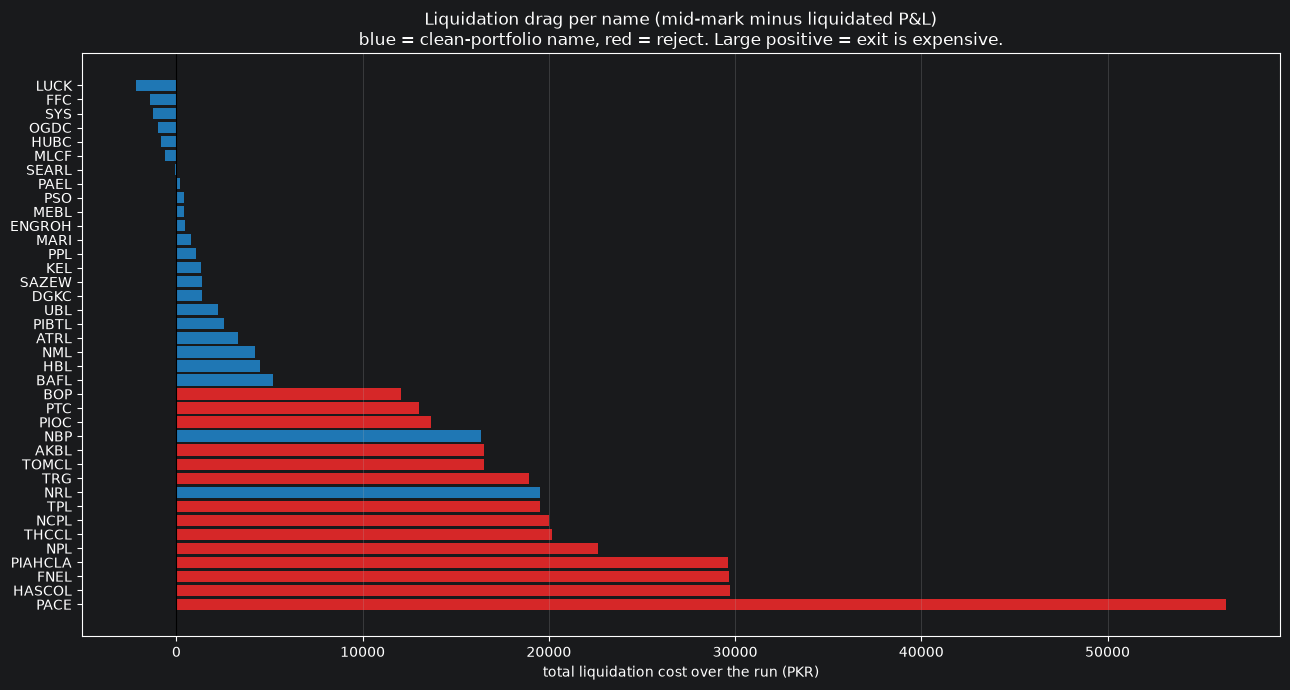

 symbol  pnl_liquidated  pnl_mid_mark  liq_drag  is_port
   PACE       -76618.81     -20283.15  56335.66    False
 HASCOL        -5139.97      24588.88  29728.85    False
   FNEL       -18992.15      10704.72  29696.87    False
PIAHCLA        18170.33      47802.36  29632.03    False
    NPL         9482.09      32117.35  22635.26    False
  THCCL        66665.19      86811.00  20145.81    False
   NCPL        47179.87      67196.82  20016.95    False
    TPL       -11626.49       7924.54  19551.03    False
    NRL        42252.30      61774.67  19522.37     True
    TRG        62757.80      81707.79  18949.99    False
  TOMCL        42866.80      59410.64  16543.84    False
   AKBL       -28315.29     -11778.21  16537.08    False


In [3]:
# liquidation drag per name = sum(mid_mark) - sum(liquidated)
liq = mid.groupby('symbol').agg(
    pnl_liquidated=('pnl_pkr','sum'),
    pnl_mid_mark=('pnl_mid_mark','sum'),
    unclean_resid=('residual_marked', lambda s: (s.fillna(0)!=0).sum()),
).reset_index()
liq['liq_drag'] = liq['pnl_mid_mark'] - liq['pnl_liquidated']
liq['is_port'] = liq['symbol'].isin(PORT)
liq = liq.sort_values('liq_drag', ascending=False)

fig, ax = plt.subplots(figsize=(13,7))
colors = np.where(liq['is_port'], '#1f77b4', '#d62728')
ax.barh(liq['symbol'], liq['liq_drag'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Liquidation drag per name (mid-mark minus liquidated P&L)\n'
             'blue = clean-portfolio name, red = reject. Large positive = exit is expensive.')
ax.set_xlabel('total liquidation cost over the run (PKR)')
ax.grid(alpha=0.3, axis='x'); plt.tight_layout(); plt.show()
print(liq[['symbol','pnl_liquidated','pnl_mid_mark','liq_drag','is_port']].head(12).to_string(index=False))

## 3. Do the leaned exits actually execute? Fills by trigger window

The unwind pulls the adding side and leans the exit at the touch during the time window. If the exit is *working*, we should see `time_ramp`/`time_cliff` fills on names that carry inventory into the close. If those counts are ~zero, the exit is posting into a dead book (the case for a taker path). Split by portfolio vs reject.

In [4]:
# window-fill totals per name
wf = mid.groupby('symbol').agg(
    total_fills=('fills','sum'),
    f_time_ramp=('fills_time_ramp','sum'),
    f_time_cliff=('fills_time_cliff','sum'),
    f_lock_ramp=('fills_lock_ramp','sum'),
    f_lock_cliff=('fills_lock_cliff','sum'),
).reset_index()
# share of fills that happened inside ANY trigger window
wf['window_fills'] = wf[['f_time_ramp','f_time_cliff','f_lock_ramp','f_lock_cliff']].sum(axis=1)
wf['pct_in_window'] = 100*wf['window_fills']/wf['total_fills']
wf['is_port'] = wf['symbol'].isin(PORT)
wf = wf.sort_values('pct_in_window', ascending=False)
print('fills executed inside a trigger window (the unwind IS getting filled where >0):')
print(wf[['symbol','total_fills','f_time_ramp','f_time_cliff','f_lock_ramp','f_lock_cliff','pct_in_window','is_port']].to_string(index=False))

fills executed inside a trigger window (the unwind IS getting filled where >0):
 symbol  total_fills  f_time_ramp  f_time_cliff  f_lock_ramp  f_lock_cliff  pct_in_window  is_port
    BOP         9961          409             9          325           107       8.533280    False
   PACE        27149          463            13         1482           191       7.915577    False
   FNEL        13421          366            10          549            99       7.629834    False
    TPL        11058          304            31          380            40       6.827636    False
PIAHCLA        24824          466            12         1028           109       6.505801    False
   PAEL        13240          486            11          280            79       6.465257     True
   HUBC         9863          429             3          154            39       6.336814     True
  THCCL        25666          576            19          924            96       6.292371    False
 HASCOL        17310         

## 4. The key question: did clean names LOSE quoting revenue to the unwind?

Compare each clean name's fills-in-window (fills it now makes during the aggressive unwind) against its P&L change vs run-1. If clean names have meaningful `time_ramp` fills AND lost P&L, the story is confirmed: the whole-window unwind pulled the adding side on names that didn't need it, sacrificing spread capture. That's the case for the inventory-gate fix.

In [5]:
# join run-1 P&L if present (older ranked file) to get the delta
olds = sorted(RESULTS.glob('universe_ranked_*.csv'))
delta = None
if len(olds) >= 2:
    old = pd.read_csv(olds[-2])
    delta = r.merge(old, on='symbol', suffixes=('_new','_old'))
    delta['dpnl'] = delta['mid_pnl_new'] - delta['mid_pnl_old']
    j = delta.merge(wf, on='symbol')
    j = j[j['symbol'].isin(PORT)].sort_values('dpnl')
    print('CLEAN NAMES: P&L change (new-old) vs their in-window fills')
    print(j[['symbol','mid_pnl_old','mid_pnl_new','dpnl','f_time_ramp','f_time_cliff','pct_in_window']].to_string(index=False))
    print(f"\nclean-portfolio total dpnl: {j['dpnl'].sum():,.0f}")
    print('If the biggest P&L LOSERS also have high time_ramp fills -> unwind stole their')
    print('quoting -> inventory-gate the unwind (only engage when genuinely loaded).')
else:
    print('only one ranked file present -- upload the run-1 ranked CSV to see the delta.')

CLEAN NAMES: P&L change (new-old) vs their in-window fills
symbol   mid_pnl_old   mid_pnl_new          dpnl  f_time_ramp  f_time_cliff  pct_in_window
   NBP  59424.617169  37561.767940 -21862.849229          489             9       4.382393
   NRL  50960.747462  42252.313333  -8708.434129          581             5       3.964758
  PAEL  53546.743196  47310.953106  -6235.790090          486            11       6.465257
   UBL 108344.735245 102789.888195  -5554.847049          419            21       3.669458
   HBL 102934.562566  97614.101780  -5320.460785          486             7       3.238583
 SEARL  81295.761736  76083.608254  -5212.153482          520             2       4.420633
  OGDC  42511.341476  38344.491148  -4166.850329          409             1       4.788603
  MLCF 100291.468190  96160.005236  -4131.462954          586            10       4.737903
   NML  63969.899861  60336.830877  -3633.068985          482            21       3.387949
  DGKC  24904.037141  21337.708

### What this decides

- **§1 residual rare** → the 10%->3% haircut was never the lever; stop attributing anything to it.
- **§2 liq-drag** → which names are exit-expensive (candidates the unwind should help) vs quoting-expensive.
- **§3-4 window fills** → whether the leaned exit executes (unwind works) and whether clean names paid for it (inventory-gate needed). If confirmed, the next code change is the `|pos| > 0.5*max_inv` gate on the unwind, then the top-10 size sweep (2x-5x) on the *fixed* strategy.